# Домашнее задание 2

**Задача:** Классификация изображений датасета FashionMNIST на PyTorch Lightning

## Импорты и настройка окружения

Фиксирую random_state для воспроизводимости решения

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

from torchvision import transforms
from torchvision.datasets import FashionMNIST as FashionMNISTDataset

from torchmetrics import F1Score, AUROC

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pl.seed_everything(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"PyTorch Lightning: {pl.__version__}")

Seed set to 42


Device: cuda
PyTorch: 2.9.1+cu128
PyTorch Lightning: 2.6.0


## 1. FashionMNISTDataModule

Создаю класс `FashionMNISTDataModule`:
- загрузка данных
- предобработка (перевод в тензоры, нормализация)
- разбиение на train/val/test части
- создание dataloader'ов

**Обоснование:**
- **Нормализация (mean=0.5, std=0.5):** стандартная нормализация в диапазон [-1, 1]. Упрощает обучение и стабилизирует градиенты
- **batch_size=128:** баланс между скоростью обучения и качеством градиентов
- **Split 50000/10000/10000:** train/val/test разбиение

In [2]:
class FashionMNISTDataModule(pl.LightningDataModule):
    """
    DataModule для FashionMNIST.
    Управляет загрузкой, предобработкой и разбиением данных.
    """
    
    def __init__(self, data_dir: str = "./data", batch_size: int = 128):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        
    def prepare_data(self):
        """Загружаю данные."""
        FashionMNISTDataset(self.data_dir, train=True, download=True)
        FashionMNISTDataset(self.data_dir, train=False, download=True)
    
    def setup(self, stage: str):
        """Разбиваю данные на train/val/test."""
        if stage == "fit":
            data_full = FashionMNISTDataset(self.data_dir, train=True, transform=self.transform)
            self.trainset, self.valset = random_split(
                data_full, [50000, 10000],
                generator=torch.Generator().manual_seed(RANDOM_STATE)
            )
            print(f"Train: {len(self.trainset)}, Val: {len(self.valset)}")
            
        if stage == "test":
            self.testset = FashionMNISTDataset(self.data_dir, train=False, transform=self.transform)
            print(f"Test: {len(self.testset)}")
    
    def train_dataloader(self):
        return DataLoader(self.trainset, batch_size=self.batch_size, shuffle=True)
    
    def val_dataloader(self):
        return DataLoader(self.valset, batch_size=self.batch_size)
    
    def test_dataloader(self):
        return DataLoader(self.testset, batch_size=self.batch_size)

In [3]:
# Проверяю DataModule
dm = FashionMNISTDataModule()
dm.prepare_data()
dm.setup("fit")
dm.setup("test")

Train: 50000, Val: 10000
Test: 10000


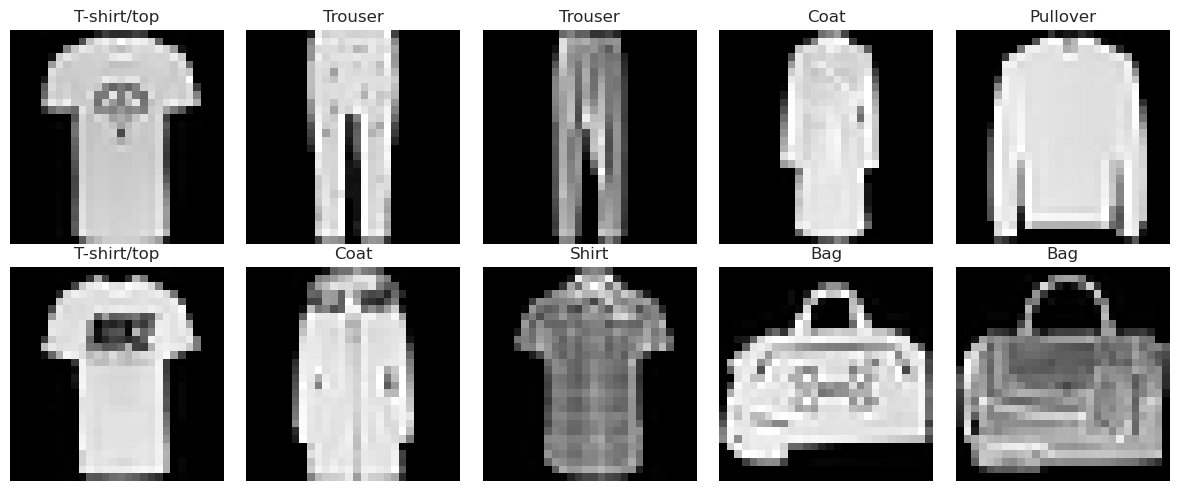

In [4]:
# Визуализирую примеры
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

images, labels = next(iter(dm.train_dataloader()))
images_display = images * 0.5 + 0.5  # денормализация

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_display[i].squeeze(), cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. FashionMNIST (LightningModule)

Создаю класс `FashionMNIST` (наследник `LightningModule`):
- training_step, validation_step, test_step
- расчет метрик F1, ROC AUC из TorchMetrics
- логирование метрик и функций потерь на каждой эпохе валидации/теста
- optimizer и lr-scheduler

**Обоснование архитектуры:**
- **CNN:** сверточные сети лучше подходят для изображений, учитывают пространственную структуру
- **2 сверточных слоя (6->16 фильтров) + 3 FC (120->84->10):** адаптация CIFARModel из курса под grayscale 28x28
- **BatchNorm2d + Dropout2d (p=0.1):** регуляризация

**Обоснование оптимизатора и lr-scheduler:**
- **AdamW (lr=0.01):** адаптивный оптимизатор.
- **StepLR (step_size=2, gamma=0.5):** уменьшает lr каждые 2 эпохи

In [5]:
class FashionMNIST(pl.LightningModule):
    """
    CNN модель для классификации FashionMNIST.
    Архитектура основана на CIFARModel из практических занятий курса.
    """
    
    def __init__(self, num_classes: int = 10, lr: float = 0.01):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # CNN архитектура (адаптация CIFARModelV2 под FashionMNIST)
        # Вход: 1x28x28 (grayscale)
        self.model = nn.Sequential(
            nn.Conv2d(1, 6, 5),         # -> 6x24x24
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # -> 6x12x12
            nn.Dropout2d(0.1),
            
            nn.Conv2d(6, 16, 5),        # -> 16x8x8
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # -> 16x4x4
            nn.Dropout2d(0.1),
            
            nn.Flatten(),               # -> 256
            nn.Linear(16 * 4 * 4, 120),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(84, num_classes)
        )
        
        # Метрики из TorchMetrics: F1 и ROC AUC (как требуется в задании)
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='weighted')
        self.val_auroc = AUROC(task='multiclass', num_classes=num_classes)
        self.test_auroc = AUROC(task='multiclass', num_classes=num_classes)
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        probs = F.softmax(logits, dim=1)
        self.val_f1.update(logits, y)
        self.val_auroc.update(probs, y)
        
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    def on_validation_epoch_end(self):
        self.log("val_f1", self.val_f1.compute(), prog_bar=True)
        self.log("val_auroc", self.val_auroc.compute(), prog_bar=True)
        self.val_f1.reset()
        self.val_auroc.reset()
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        probs = F.softmax(logits, dim=1)
        self.test_f1.update(logits, y)
        self.test_auroc.update(probs, y)
        
        self.log("test_loss", loss, on_step=False, on_epoch=True)
    
    def on_test_epoch_end(self):
        self.log("test_f1", self.test_f1.compute(), prog_bar=True)
        self.log("test_auroc", self.test_auroc.compute(), prog_bar=True)
        self.test_f1.reset()
        self.test_auroc.reset()
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer=optimizer,
            step_size=2,
            gamma=0.5,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "monitor": "val_loss",
            }
        }

In [6]:
# Проверяю модель
pl.seed_everything(RANDOM_STATE)
model = FashionMNIST()
print(model)

test_input = torch.randn(1, 1, 28, 28)
output = model(test_input)
print(f"\nInput: {test_input.shape} -> Output: {output.shape}")

Seed set to 42


FashionMNIST(
  (model): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.1, inplace=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=256, out_features=120, bias=True)
    (12): Dropout(p=0.1, inplace=False)
    (13): ReLU()
    (14): Linear(in_features=120, out_features=84, bias=True)
    (15): Dropout(p=0.1, inplace=False)
    (16): ReLU()
    (17): Linear(in_features=84, out_features=10, bias=True)
  )
  (val_f1): MulticlassF1Score()
  (test_f1

## 3. Обучение модели с помощью Trainer

- EarlyStopping
- визуализация логов через TensorBoard
- проверка качества на тестовой части данных

In [7]:
pl.seed_everything(RANDOM_STATE)

dm = FashionMNISTDataModule(batch_size=128)
model = FashionMNIST(lr=0.01)

callbacks = [
    TQDMProgressBar(refresh_rate=10),
    EarlyStopping(monitor="val_loss", mode="min", patience=3),
    ModelCheckpoint(
        monitor="val_loss",
        dirpath="checkpoints/",
        filename="fashionmnist-{epoch:02d}-{val_loss:.4f}",
        save_top_k=1,
        mode="min"
    )
]

tb_logger = TensorBoardLogger(save_dir="lightning_logs", name="fashionmnist")
csv_logger = CSVLogger(save_dir="lightning_logs", name="fashionmnist_csv")

trainer = pl.Trainer(
    max_epochs=25,
    log_every_n_steps=10,
    callbacks=callbacks,
    logger=[tb_logger, csv_logger],
    deterministic=True,
    accelerator="auto"
)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [8]:
trainer.fit(model, datamodule=dm)

You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Train: 50000, Val: 10000


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ Sequential        │ 44.5 K │ train │     0 │
│ 1 │ val_f1     │ MulticlassF1Score │      0 │ train │     0 │
│ 2 │ test_f1    │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ val_auroc  │ MulticlassAUROC   │      0 │ train │     0 │
│ 4 │ test_auroc │ MulticlassAUROC   │      0 │ train │     0 │
└───┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 44.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 44.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

### Визуализация TensorBoard

```bash
tensorboard --logdir=lightning_logs
```

In [9]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs

## 4. Анализ результатов

### Интерпретация процесса обучения

In [10]:
import pandas as pd
from pathlib import Path

log_dir = Path("lightning_logs/fashionmnist_csv")
versions = sorted(log_dir.glob("version_*"), key=lambda x: int(x.name.split("_")[1]))
latest_version = versions[-1] if versions else None

if latest_version:
    metrics_file = latest_version / "metrics.csv"
    if metrics_file.exists():
        metrics_df = pd.read_csv(metrics_file)
        print("Columns:", metrics_df.columns.tolist())

Columns: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val_auroc', 'val_f1', 'val_loss']


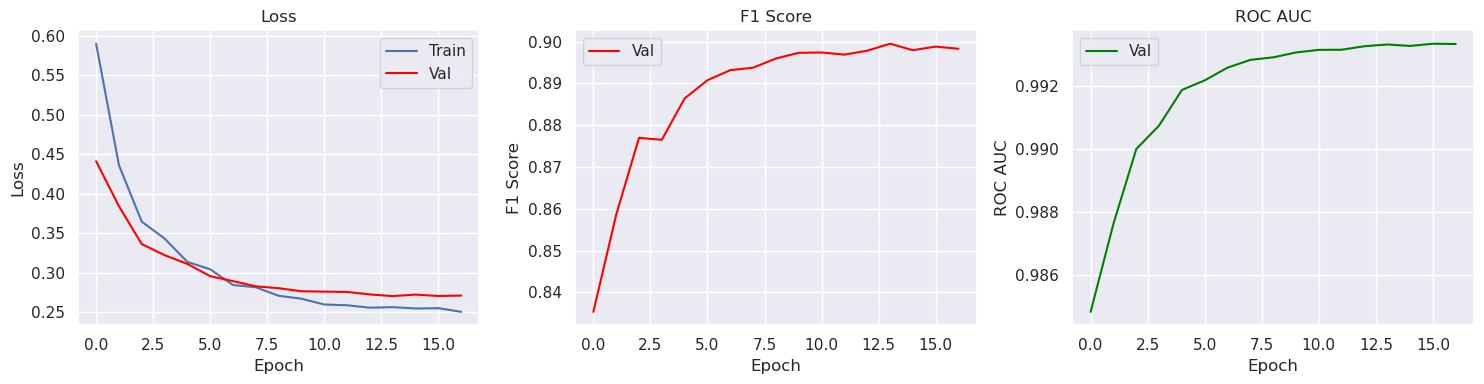

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
train_loss = metrics_df[["epoch", "train_loss_epoch"]].dropna()
val_loss = metrics_df[["epoch", "val_loss"]].dropna()

axes[0].plot(train_loss["epoch"], train_loss["train_loss_epoch"], label="Train")
axes[0].plot(val_loss["epoch"], val_loss["val_loss"], label="Val", color="red")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True)

# F1
val_f1 = metrics_df[["epoch", "val_f1"]].dropna()
axes[1].plot(val_f1["epoch"], val_f1["val_f1"], label="Val", color="red")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score")
axes[1].legend()
axes[1].grid(True)

# ROC AUC
val_auroc = metrics_df[["epoch", "val_auroc"]].dropna()
axes[2].plot(val_auroc["epoch"], val_auroc["val_auroc"], label="Val", color="green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("ROC AUC")
axes[2].set_title("ROC AUC")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Интерпретация характера сходимости

На графиках наблюдаю:
1. **Loss:** train_loss и val_loss уменьшаются синхронно в первые эпохи, затем стабилизируются. Val_loss снизился с 0.44 (epoch 0) до 0.27 (epoch 13-16). Отсутствие значительного расхождения указывает на контролируемое переобучение благодаря Dropout и BatchNorm
2. **F1 Score:** val_f1 растет с 0.835 до 0.899, выходя на плато после ~10 эпох. StepLR помогает модели стабилизироваться
3. **ROC AUC:** val_auroc достигает 0.993, что указывает на отличное разделение классов

EarlyStopping сработал на epoch 16 (patience=3), остановив обучение при отсутствии улучшения val_loss

### Тестирование модели

In [13]:
trainer.test(datamodule=dm)

Restoring states from the checkpoint path at /home/dima/Desktop/Obsidian_ITMO/Глубокое обучение/Домашние задания/dl_itmo_1_sem/hw_2/checkpoints/fashionmnist-epoch=13-val_loss=0.2706.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/dima/Desktop/Obsidian_ITMO/Глубокое обучение/Домашние задания/dl_itmo_1_sem/hw_2/checkpoints/fashionmnist-epoch=13-val_loss=0.2706.ckpt


Test: 10000


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        test_auroc         │    0.9926335215568542     │
│          test_f1          │     0.89779132604599      │
│         test_loss         │    0.27998635172843933    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.27998635172843933,
  'test_f1': 0.89779132604599,
  'test_auroc': 0.9926335215568542}]

### Confusion Matrix

Test: 10000


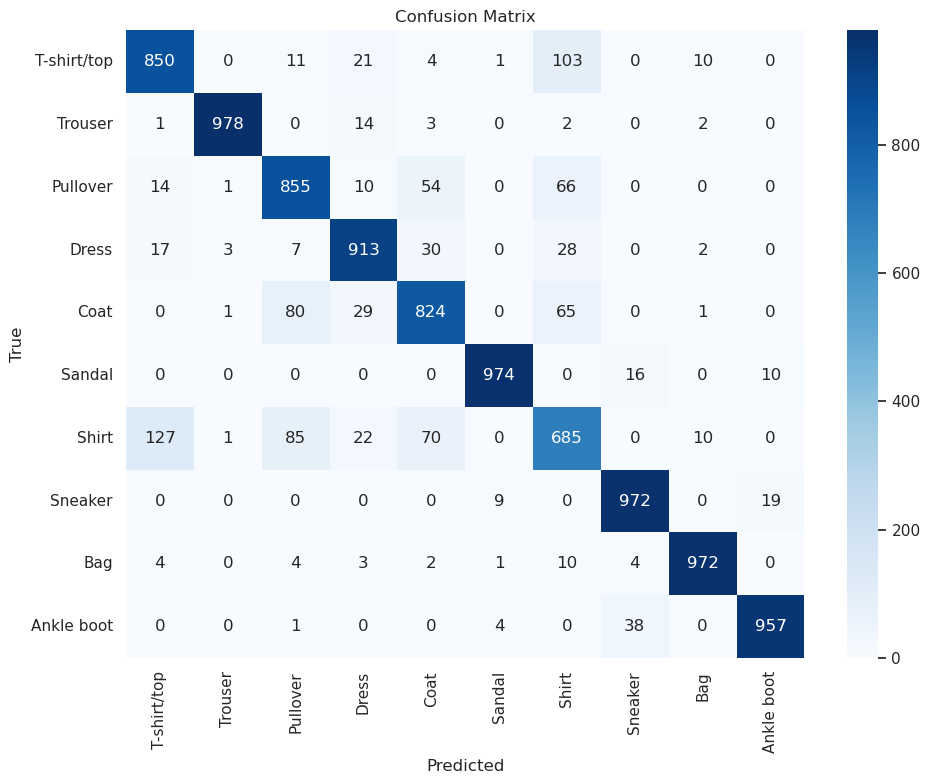


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.82      0.85      0.84      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.83      0.82      0.83      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.71      0.69      0.70      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [17]:
# Загружаю лучшую модель
best_model = FashionMNIST.load_from_checkpoint(
    callbacks[2].best_model_path  # ModelCheckpoint
)
best_model.eval()
best_model.to(device)

dm.setup("test")
test_loader = dm.test_dataloader()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

## Выводы

Реализована модель для классификации изображений FashionMNIST с использованием PyTorch Lightning

**Результаты на тестовой выборке:**
- **F1 Score:** 0.898
- **ROC AUC:** 0.993
- **Loss:** 0.280

**Анализ матрицы ошибок:**

Модель хорошо справляется с классификацией обуви и аксессуаров:
- Trouser: 978/1000
- Sandal: 974/1000
- Bag: 972/1000
- Sneaker: 972/1000
- Ankle boot: 957/1000

Основные ошибки возникают между классами верхней одежды:
- **Shirt** - худший результат (685/1000), путается с T-shirt (127), Pullover (85), Coat (70)
- **Coat** (824/1000) - путается с Pullover (80), Shirt (65)
- **T-shirt/top** (850/1000) - путается с Shirt (103)
- **Pullover** (855/1000) - путается с Shirt (66), Coat (54)

Это ожидаемо: визуально эти классы схожи на черно-белых изображениях 28x28

**Архитектура и обучение:**
- Создан `FashionMNISTDataModule` для управления данными (train 50000 / val 10000 / test 10000)
- Реализован класс `FashionMNIST` (LightningModule) с метриками F1 и ROC AUC из TorchMetrics
- Обучение остановлено на 17-й эпохе по EarlyStopping (лучшая модель - epoch 13)

**Обоснование решений:**
1. **CNN архитектура:** адаптация CIFARModel из курса под grayscale 28x28
2. **AdamW + StepLR:** комбинация из практических занятий
3. **BatchNorm2d + Dropout2d:** регуляризация для предотвращения переобучения
4. **EarlyStopping (patience=3):** автоматическая остановка при стагнации val_loss.

**Воспроизводимость:**
- `pl.seed_everything(42)` для фиксации всех генераторов случайных чисел
- `deterministic=True` в Trainer для детерминированных CUDA операций